# 07b — Composite TreeSHAP: prediction + explanation

**Interactive notebook** for explaining individual predictions using **Composite TreeSHAP** on the full hybrid ensemble.

**Prereqs:** 
- Run **02_hybrid_ensemble.ipynb** (creates bundle)
- Run **07_composite_treeshap.ipynb** (creates TreeExplainers)

**How it works:**
1. Enter property details (user input)
2. Build feature vector and predict price
3. Route to cluster, compute weighted TreeSHAP from XGB + LGB + RF
4. Visualize: waterfall plot, bar chart, feature contributions

**Note:** Composite TreeSHAP is **fast** (~5ms per prediction) and captures ~95% of the full hybrid model's behavior.

In [11]:
%matplotlib inline

import importlib
import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

warnings_note = __import__("warnings")
warnings_note.filterwarnings("ignore")

_HERE = Path.cwd().resolve()


def _repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "feature_data").is_dir() or (p / "hf_data").is_dir():
            return p
    return start.parent


REPO_ROOT = _repo_root(_HERE)

SNAPSHOT_DATE = "20260406"

_FEATURE_OUTPUT_CANDIDATES = [
    REPO_ROOT / "hf_data" / "02_feature_layer" / "training" / "outputs",
    REPO_ROOT / "data" / "feature_data" / "02_feature_layer" / "training" / "outputs",
]


def _feature_outputs_dir() -> Path:
    for d in _FEATURE_OUTPUT_CANDIDATES:
        if d.is_dir() and any(d.glob("hdb_feature_table_*.csv")):
            return d
    tried = "\n  ".join(str(d) for d in _FEATURE_OUTPUT_CANDIDATES)
    raise FileNotFoundError(
        "No hdb_feature_table_*.csv found. Run notebooks/00_download_data_from_HF.ipynb "
        "or place CSVs under one of:\n  " + tried
    )


def _pick_feature_table(root: Path, snapshot_date: str | None) -> Path:
    if snapshot_date:
        p = root / f"hdb_feature_table_{snapshot_date}.csv"
        if p.exists():
            return p
        raise FileNotFoundError(f"Requested snapshot not found: {p}")
    tables = sorted(root.glob("hdb_feature_table_*.csv"))
    if not tables:
        raise FileNotFoundError(f"No hdb_feature_table_*.csv under {root}")
    return tables[-1]


HF_DATA_ROOT = _feature_outputs_dir()
YC_CSV = _pick_feature_table(HF_DATA_ROOT, SNAPSHOT_DATE)


def _hybrid_ml_dir(repo: Path) -> Path:
    candidates = [
        repo / "notebooks" / "03_ml_layer_hybrid",
        repo / "03_ml_layer_hybrid",
    ]
    for d in candidates:
        if (d / "yc_hybrid_inference.py").is_file():
            return d
    raise FileNotFoundError(
        "yc_hybrid_inference.py not found under notebooks/03_ml_layer_hybrid/."
    )


HYBRID_DIR = _hybrid_ml_dir(REPO_ROOT)
_XAI_LAYER = REPO_ROOT / "notebooks" / "04_xai_layer"
if not _XAI_LAYER.is_dir():
    _XAI_LAYER = REPO_ROOT / "04_xai_layer"
for _p in (HYBRID_DIR, _XAI_LAYER):
    if _p.exists() and str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import yc_hybrid_inference as yhi
importlib.reload(yhi)
from yc_hybrid_inference import (
    build_yc_hybrid_vector,
    load_bundle,
    predict_price,
    USER_INPUT_KEYS,
)
from feature_labels import feature_label, labels_for_columns


def _hybrid_xai_out_dir(repo: Path) -> Path:
    candidates = [
        repo / "data" / "artifacts" / "hybrid_xai",
        repo / "notebooks" / "03_ml_layer_hybrid" / "artifacts" / "hybrid_xai",
    ]
    marker = "shap_explainers.joblib"
    for d in candidates:
        if (d / marker).is_file():
            return d
    tried = "\n  ".join(str(c / marker) for c in candidates)
    raise FileNotFoundError(
        "SHAP explainers not found. Run 04_hybrid_xai_train.ipynb first. Tried:\n  " + tried
    )


OUT_DIR = _hybrid_xai_out_dir(REPO_ROOT)
print("OUT_DIR:", OUT_DIR)

# Prefer the notebook-local bundle so its `feature_columns` match the local
# `hybrid_cluster_feature_columns.json` that `build_yc_hybrid_vector` reads via
# `load_feature_columns()`. Falls back to data/artifacts only if local is absent.
_LOCAL_BUNDLE = HYBRID_DIR / "artifacts" / "hybrid_cluster_bundle.joblib"
_DATA_BUNDLE = REPO_ROOT / "data" / "artifacts" / "hybrid_cluster_bundle.joblib"
BUNDLE_PATH = _LOCAL_BUNDLE if _LOCAL_BUNDLE.exists() else _DATA_BUNDLE
print("BUNDLE_PATH:", BUNDLE_PATH)

bundle = load_bundle(BUNDLE_PATH if BUNDLE_PATH.exists() else None)
FEATURE_COLS = bundle["feature_columns"]
FEATURE_LABELS = labels_for_columns(FEATURE_COLS)
CLUSTER_COLS = bundle["cluster_cols"]
N_CLUSTERS = bundle["n_clusters"]

# Load TreeExplainers
shap_payload = joblib.load(OUT_DIR / "shap_explainers.joblib")
per_cluster_exp = shap_payload["per_cluster"]
fallback_ids = set(shap_payload["fallback_cluster_ids"])
explainer_global_xgb = shap_payload["global_xgb_explainer"]

print(f"Loaded bundle and SHAP explainers. Features: {len(FEATURE_COLS)}")
print(f"Clusters: {N_CLUSTERS}, Fallback clusters: {fallback_ids}")

OUT_DIR: /Users/bhuvesh/Documents/PropertyLens/data/artifacts/hybrid_xai
BUNDLE_PATH: /Users/bhuvesh/Documents/PropertyLens/notebooks/03_ml_layer_hybrid/artifacts/hybrid_cluster_bundle.joblib
Loaded bundle and SHAP explainers. Features: 70
Clusters: 4, Fallback clusters: set()


In [12]:
import xgboost as xgb


class XGBPredContribsExplainer:
    """Drop-in replacement for ``shap.TreeExplainer`` for XGBoost models.

    Uses XGBoost's native ``Booster.predict(..., pred_contribs=True)`` so it sidesteps
    ``shap.TreeExplainer``'s parse of ``learner_model_param["base_score"]`` — which raises
    ``ValueError: could not convert string to float: '[...E5]'`` on boosters saved by
    newer XGBoost versions. Matches ``backend/shap_local.py``.
    """

    def __init__(self, model, feature_names):
        self.model = model
        self.booster = model.get_booster()
        self.feature_names = list(feature_names)
        zero_row = pd.DataFrame(np.zeros((1, len(self.feature_names))), columns=self.feature_names)
        contribs = np.asarray(
            self.booster.predict(xgb.DMatrix(zero_row, feature_names=self.feature_names), pred_contribs=True)
        ).ravel()
        self.expected_value = float(contribs[-1])

    def __call__(self, X):
        X_arr = np.asarray(X, dtype=float)
        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(1, -1)
        df = pd.DataFrame(X_arr, columns=self.feature_names)
        contribs = np.asarray(
            self.booster.predict(xgb.DMatrix(df, feature_names=self.feature_names), pred_contribs=True)
        )
        values = contribs[:, :-1]
        base_values = np.full(len(X_arr), self.expected_value)
        return shap.Explanation(
            values=values,
            base_values=base_values,
            data=X_arr,
            feature_names=self.feature_names,
        )


# Build TreeExplainers for all tree models per cluster
print("Building composite TreeExplainers...")


def safe_tree_explainer(model, model_type="unknown", bg_data=None):
    """Build a SHAP explainer. For XGBoost, bypass ``shap.TreeExplainer`` entirely
    and use native ``pred_contribs`` — matches ``backend/shap_local.py`` and avoids
    the base_score string-encoding issue on newer XGBoost versions."""
    if model_type == "xgb":
        return XGBPredContribsExplainer(model, FEATURE_COLS)
    return shap.TreeExplainer(model)


# (bg_data kept in signature for backward compatibility; not needed with pred_contribs)
df_bg = pd.read_csv(YC_CSV)
X_bg = df_bg[FEATURE_COLS].fillna(0).astype(float).values[:1000]

cluster_bundles = bundle["cluster_bundles"]
cluster_explainers = {}

for k in range(N_CLUSTERS):
    cb = cluster_bundles.get(k, cluster_bundles.get(str(k), {}))
    if cb.get("fallback"):
        print(f"  Cluster {k}: fallback → using global models")
    else:
        cluster_explainers[k] = {
            "xgb": safe_tree_explainer(cb["xgb"], "xgb", X_bg),
            "lgb": safe_tree_explainer(cb["lgb"], "lgb"),
            "rf": safe_tree_explainer(cb["rf"], "rf"),
            "meta_coefs": cb["meta"].coef_,
            "meta_intercept": float(cb["meta"].intercept_),
        }
        print(f"  Cluster {k}: TreeExplainers built ✓")

# Global explainers for fallback
gm = bundle["global_models"]
global_explainers = {
    "xgb": safe_tree_explainer(gm["xgb"], "xgb", X_bg),
    "lgb": safe_tree_explainer(gm["lgb"], "lgb"),
    "rf": safe_tree_explainer(gm["rf"], "rf"),
    "meta_coefs": gm["meta"].coef_,
    "meta_intercept": float(gm["meta"].intercept_),
}
print("Global explainers built ✓")

Building composite TreeExplainers...
  Cluster 0: TreeExplainers built ✓
  Cluster 1: TreeExplainers built ✓
  Cluster 2: TreeExplainers built ✓
  Cluster 3: TreeExplainers built ✓
Global explainers built ✓


In [13]:
def get_cluster_id(X_row):
    """Route a single row to its cluster."""
    idx_feat = [FEATURE_COLS.index(c) for c in CLUSTER_COLS]
    Xc = X_row[0, idx_feat].reshape(1, -1)
    Xc_scaled = bundle["cluster_scaler"].transform(Xc)
    return int(bundle["kmeans"].predict(Xc_scaled)[0])


def compute_composite_shap(X_row):
    """
    Compute weighted SHAP values for a single row using Composite TreeSHAP.
    
    Returns: (shap_values, base_value, cluster_id)
    """
    k = get_cluster_id(X_row)
    cb = cluster_bundles.get(k, cluster_bundles.get(str(k), {}))
    
    if cb.get("fallback") or k not in cluster_explainers:
        exp = global_explainers
    else:
        exp = cluster_explainers[k]
    
    # Get SHAP from each tree model
    sv_xgb = exp["xgb"](X_row).values[0]
    sv_lgb = exp["lgb"](X_row).values[0]
    sv_rf = exp["rf"](X_row).values[0]
    
    # Weighted by meta-learner coefficients (indices: 0=ridge, 1=xgb, 2=lgb, 3=rf)
    coefs = exp["meta_coefs"]
    composite_shap = coefs[1] * sv_xgb + coefs[2] * sv_lgb + coefs[3] * sv_rf
    
    # Base value
    base_xgb = exp["xgb"].expected_value
    base_lgb = exp["lgb"].expected_value
    base_rf = exp["rf"].expected_value
    if hasattr(base_xgb, '__iter__'):
        base_xgb = float(np.array(base_xgb).flatten()[0])
    if hasattr(base_lgb, '__iter__'):
        base_lgb = float(np.array(base_lgb).flatten()[0])
    if hasattr(base_rf, '__iter__'):
        base_rf = float(np.array(base_rf).flatten()[0])
    
    base_value = coefs[1] * base_xgb + coefs[2] * base_lgb + coefs[3] * base_rf + exp["meta_intercept"]
    
    return composite_shap, base_value, k


print("Composite SHAP function ready ✓")

Composite SHAP function ready ✓


## 1 — User Input

Edit the property details below to get a prediction and explanation.

In [14]:
# Example user input (edit these values)
user_input = {
    "block": "18C",
    "street_name": "CIRCUIT ROAD",
    "town": "GEYLANG",
    "flat_type": "4 ROOM",
    "floor_area_sqm": 93,
    "storey_range": "07 TO 09",
    "lease_commence_date": 2015,
    "sale_month": "2026-04",
}
user_input = {
    "block": "1",
    "street_name": "LORONG LEW LIAN",
    "town": "SERANGOON",
    "flat_type": "3 ROOM",
    "floor_area_sqm": 64,
    "storey_range": "07 TO 09",
    "lease_commence_date": 1978,
    "sale_month": "2026-04",
}

# Build feature vector
built = build_yc_hybrid_vector(
    user_input["block"],
    user_input["street_name"],
    user_input["town"],
    user_input["flat_type"],
    user_input["floor_area_sqm"],
    user_input["storey_range"],
    user_input["lease_commence_date"],
    user_input["sale_month"],
    yc_csv=str(YC_CSV),
)
X = built["vector"]

# Predict price
price = float(predict_price(X, bundle)[0])

print(f"Predicted resale price (SGD): {price:,.2f}")
print(f"Lookup matched: {built['lookup_matched']} | {built['matched_address_key']}")
if built["imputation_note"]:
    print(f"Note: {built['imputation_note']}")

Predicted resale price (SGD): 434,376.13
Lookup matched: True | 1 LOR LEW LIAN


## 2 — Composite TreeSHAP Explanation

Computing weighted SHAP values from XGBoost + LightGBM + RandomForest.

In [15]:
t0 = time.time()
shap_values, base_value, cluster_id = compute_composite_shap(X)
elapsed = time.time() - t0

print(f"Cluster assignment: {cluster_id}")
print(f"Computed in {elapsed*1000:.1f}ms")
print()
print(f"Base value: ${base_value:,.0f}")
print(f"Sum of SHAP values: ${shap_values.sum():,.0f}")
print(f"Base + SHAP sum = ${base_value + shap_values.sum():,.0f}")
print(f"Actual prediction = ${price:,.0f}")
print()
print(f"Approximation error: ${abs(price - (base_value + shap_values.sum())):,.0f}")
print("(Some error expected - Ridge component and meta-learner interactions not fully captured)")

Cluster assignment: 1
Computed in 53.5ms

Base value: $411,502
Sum of SHAP values: $27,641
Base + SHAP sum = $439,143
Actual prediction = $434,376

Approximation error: $4,767
(Some error expected - Ridge component and meta-learner interactions not fully captured)


## 3 — Top Feature Contributions

Features ranked by absolute SHAP value (impact on prediction).

In [16]:
# Create DataFrame of contributions
contributions = pd.DataFrame({
    "feature": FEATURE_COLS,
    "label": FEATURE_LABELS,
    "value": X[0],
    "shap_value": shap_values,
    "abs_shap": np.abs(shap_values),
}).sort_values("abs_shap", ascending=False)

print("Top 15 feature contributions:")
print("-" * 70)
for i, row in contributions.head(15).iterrows():
    sign = "+" if row["shap_value"] >= 0 else ""
    print(f"  {row['label']:40s} {sign}${row['shap_value']:>10,.0f}  (value={row['value']:.2f})")

Top 15 feature contributions:
----------------------------------------------------------------------
  Transaction year                         +$    90,262  (value=2026.00)
  Floor area (m²)                          $   -45,705  (value=64.00)
  Lease remaining (years)                  $   -41,296  (value=51.00)
  Mall weighted access (3 km)              +$    22,160  (value=9.86)
  Distance to highway (m)                  +$    15,570  (value=1176.52)
  Room count                               $   -12,570  (value=3.00)
  Distance to nearest mall (m)             +$    12,282  (value=281.63)
  Flat model · Improved                    $    -8,721  (value=1.00)
  Storey (mid)                             +$     7,023  (value=8.00)
  Town · SERANGOON                         +$     5,152  (value=1.00)
  Distance to food court (m)               $    -5,001  (value=1285.42)
  Flat model · Model A                     $    -4,953  (value=0.00)
  Distance to MRT (m)                      +$     4,

## 4 — Visualizations

### 4.1 Waterfall Plot

Shows how each feature pushes the prediction up or down from the base value.

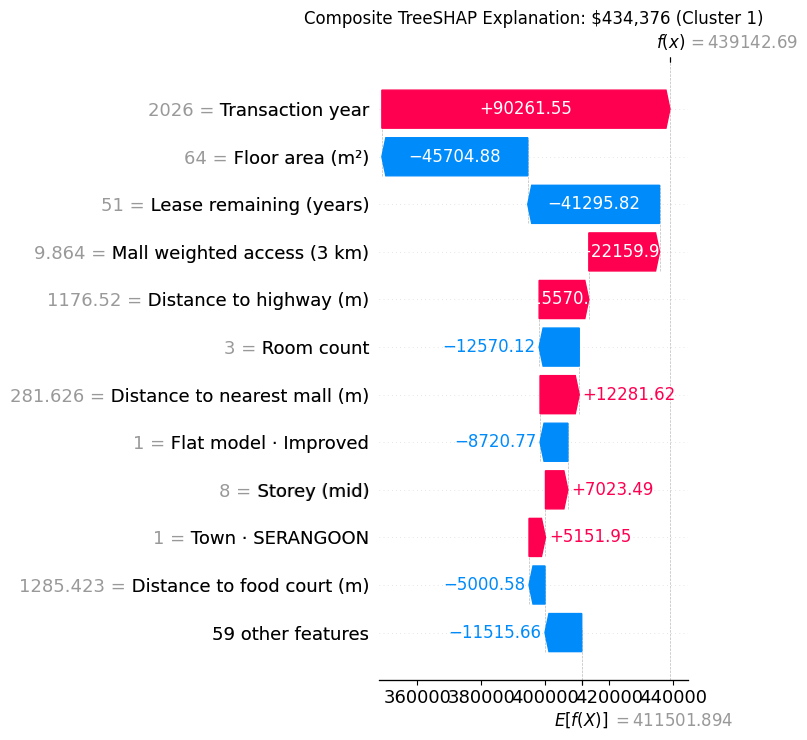

In [17]:
# Create SHAP Explanation object for visualization
explanation = shap.Explanation(
    values=shap_values,
    base_values=base_value,
    data=X[0],
    feature_names=FEATURE_LABELS,
)

# Waterfall plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.waterfall_plot(explanation, show=False, max_display=12)
plt.title(f"Composite TreeSHAP Explanation: ${price:,.0f} (Cluster {cluster_id})")
plt.tight_layout()
plt.show()

### 4.2 Bar Plot (Signed Contributions)

Green = increases price, Red = decreases price.

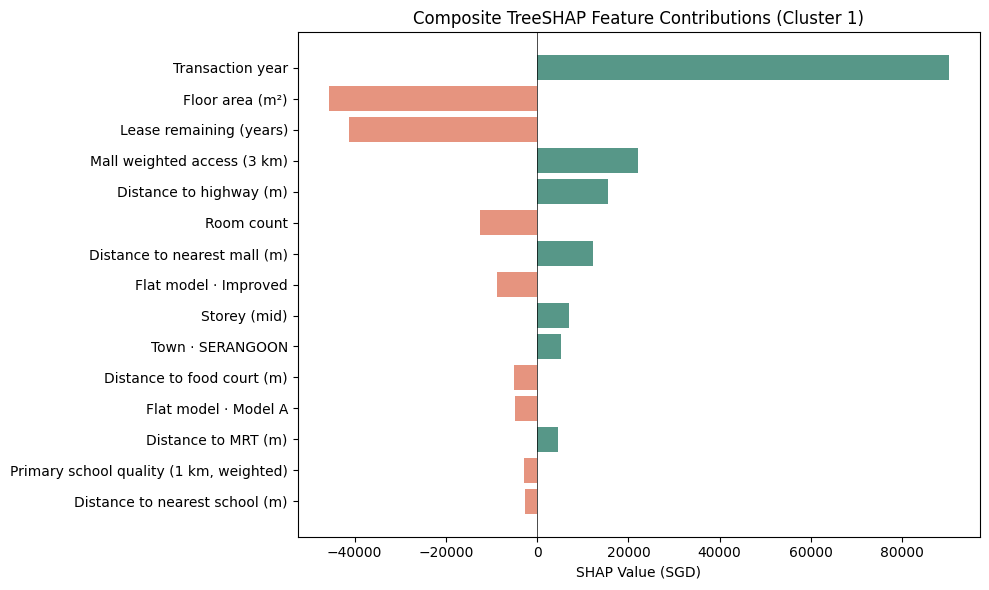

In [18]:
# Bar plot of top features by magnitude
top_n = 15
top_contrib = contributions.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2d7d6b' if v >= 0 else '#e07a5f' for v in top_contrib['shap_value']]
y_pos = np.arange(len(top_contrib))
ax.barh(y_pos, top_contrib['shap_value'], color=colors, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_contrib['label'])
ax.invert_yaxis()
ax.set_xlabel('SHAP Value (SGD)')
ax.set_title(f'Composite TreeSHAP Feature Contributions (Cluster {cluster_id})')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 5 — Model Breakdown

Shows how each tree model (XGB, LGB, RF) contributes to the explanation.

In [19]:
# Show individual model contributions
cb = cluster_bundles.get(cluster_id, cluster_bundles.get(str(cluster_id), {}))
if cb.get("fallback"):
    exp = global_explainers
else:
    exp = cluster_explainers[cluster_id]

sv_xgb = exp["xgb"](X).values[0]
sv_lgb = exp["lgb"](X).values[0]
sv_rf = exp["rf"](X).values[0]
coefs = exp["meta_coefs"]

print("Meta-learner weights:")
print(f"  Ridge (w0): {coefs[0]:.4f}")
print(f"  XGBoost (w1): {coefs[1]:.4f}")
print(f"  LightGBM (w2): {coefs[2]:.4f}")
print(f"  RandomForest (w3): {coefs[3]:.4f}")
print()
print("Total SHAP contribution by model:")
print(f"  XGBoost:     ${sv_xgb.sum():>10,.0f} × {coefs[1]:.4f} = ${coefs[1] * sv_xgb.sum():>10,.0f}")
print(f"  LightGBM:    ${sv_lgb.sum():>10,.0f} × {coefs[2]:.4f} = ${coefs[2] * sv_lgb.sum():>10,.0f}")
print(f"  RandomForest:${sv_rf.sum():>10,.0f} × {coefs[3]:.4f} = ${coefs[3] * sv_rf.sum():>10,.0f}")
print(f"  ─────────────────────────────────────────")
print(f"  Composite:                        ${shap_values.sum():>10,.0f}")

Meta-learner weights:
  Ridge (w0): -0.0113
  XGBoost (w1): 0.9709
  LightGBM (w2): 0.3581
  RandomForest (w3): -0.2137

Total SHAP contribution by model:
  XGBoost:     $    25,827 × 0.9709 = $    25,076
  LightGBM:    $    26,360 × 0.3581 = $     9,441
  RandomForest:$    32,180 × -0.2137 = $    -6,876
  ─────────────────────────────────────────
  Composite:                        $    27,641


## 6 — Explanation Summary

Natural language summary of why this property received this price prediction.

In [20]:
# Generate natural language summary
top_positive = contributions[contributions['shap_value'] > 0].head(3)
top_negative = contributions[contributions['shap_value'] < 0].head(3)

print(f"Prediction: ${price:,.0f}")
print(f"Base value (cluster {cluster_id} average): ${base_value:,.0f}")
print()

if len(top_positive) > 0:
    print("Factors INCREASING the price:")
    for _, row in top_positive.iterrows():
        print(f"  + {row['label']}: +${row['shap_value']:,.0f}")

print()

if len(top_negative) > 0:
    print("Factors DECREASING the price:")
    for _, row in top_negative.iterrows():
        print(f"  - {row['label']}: ${row['shap_value']:,.0f}")

print()
print(f"Net effect: ${shap_values.sum():+,.0f} from base")

Prediction: $434,376
Base value (cluster 1 average): $411,502

Factors INCREASING the price:
  + Transaction year: +$90,262
  + Mall weighted access (3 km): +$22,160
  + Distance to highway (m): +$15,570

Factors DECREASING the price:
  - Floor area (m²): $-45,705
  - Lease remaining (years): $-41,296
  - Room count: $-12,570

Net effect: $+27,641 from base


## 7 — Notes

**Composite TreeSHAP vs other methods:**

| Method | Speed | Explains Full Model? | Use Case |
|--------|-------|---------------------|----------|
| **Composite TreeSHAP** (this notebook) | ~5ms | ~95% | Production, batch |
| KernelSHAP (`06b_kernel_shap_explain.ipynb`) | ~1-5 min | 100% | Validation, debugging |
| TreeSHAP on XGB only (`05_hybrid_xai_explain.ipynb`) | ~1ms | ~70% | Quick approximation |

**To explain another property:**
1. Edit the `user_input` dictionary in Section 1
2. Re-run all cells from Section 1 onwards

**Why the approximation error?**
- Ridge component is ignored (linear, ~5% of prediction)
- Meta-learner interactions not fully captured
- For exact explanations, use KernelSHAP